In [1]:
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import sys
sys.path.append('.')

from utils import *
from experiment import *
from dataloader.vlfc import COMPANIES
from visualize import *

# Quick start with a single experiment

We start with runing a single time series forecasting experiment. We will run return forecasting problem on AMD stock return with baseline adapative conformal inference (ACI) methods.

### Load the hyper parameters of the model

The first step is to load the config file in `bellman-conformal-inference/config`.

In [2]:
params = read_yaml('config/rtfc-aci-AMD.yaml')

The naming of the config file follows the convention of `TASK_NAME-METHOD_NAME-TASK_DATASET.yaml`. In this case, the config file looks like

```
> params

{'task': 'rtfc',        # the return forecasting problem, avalibale choices ['rtfc', 'vlfc']
 'method': 'aci',       # the adapative conformal algorithm to use. 'aci' means baseline Adapative Conformal Algorithm
 'id': 'AMD',           # the dataset to be used by the experiment. They can be found in 'data/'
 'alpha0': 0.1,         # target miscoverage rate. In this case 10%
 'gamma': 0.1,          # step size for either ACI or BCI
 'lambda_init': 0.9,
 'lambda_max': 1.0,
 'lambda_min': 0.0}
```

We can run the experiment by using the `.run()` method, which captures all the details of computing $\alpha_t$ for each $t$. To hack around the code, please see `experiment.py` for the logic of computing $\alpha_t$.

### Build the experiment object and run the experiment

The experiment object created by

In [3]:
exp = ForecastingExperiment(params)

In [4]:
exp.run()

2026-03-02 11:56:26,257 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 STARTED


2026-03-02 11:56:28,674 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 ENDED in 2.4171392917633057s


After we run the experiment, we can optionally save the experiment. They will be saved in `bellman-conformal-inference/result/*`. This include the full trajectory of the experiment, and the hyper parameter used.

In [5]:
exp.save()

Finally, we can visualize the experiment by calling the `visualize_single_exp(**)` function defined in `bellman-conformal-inference/visualize.py`.

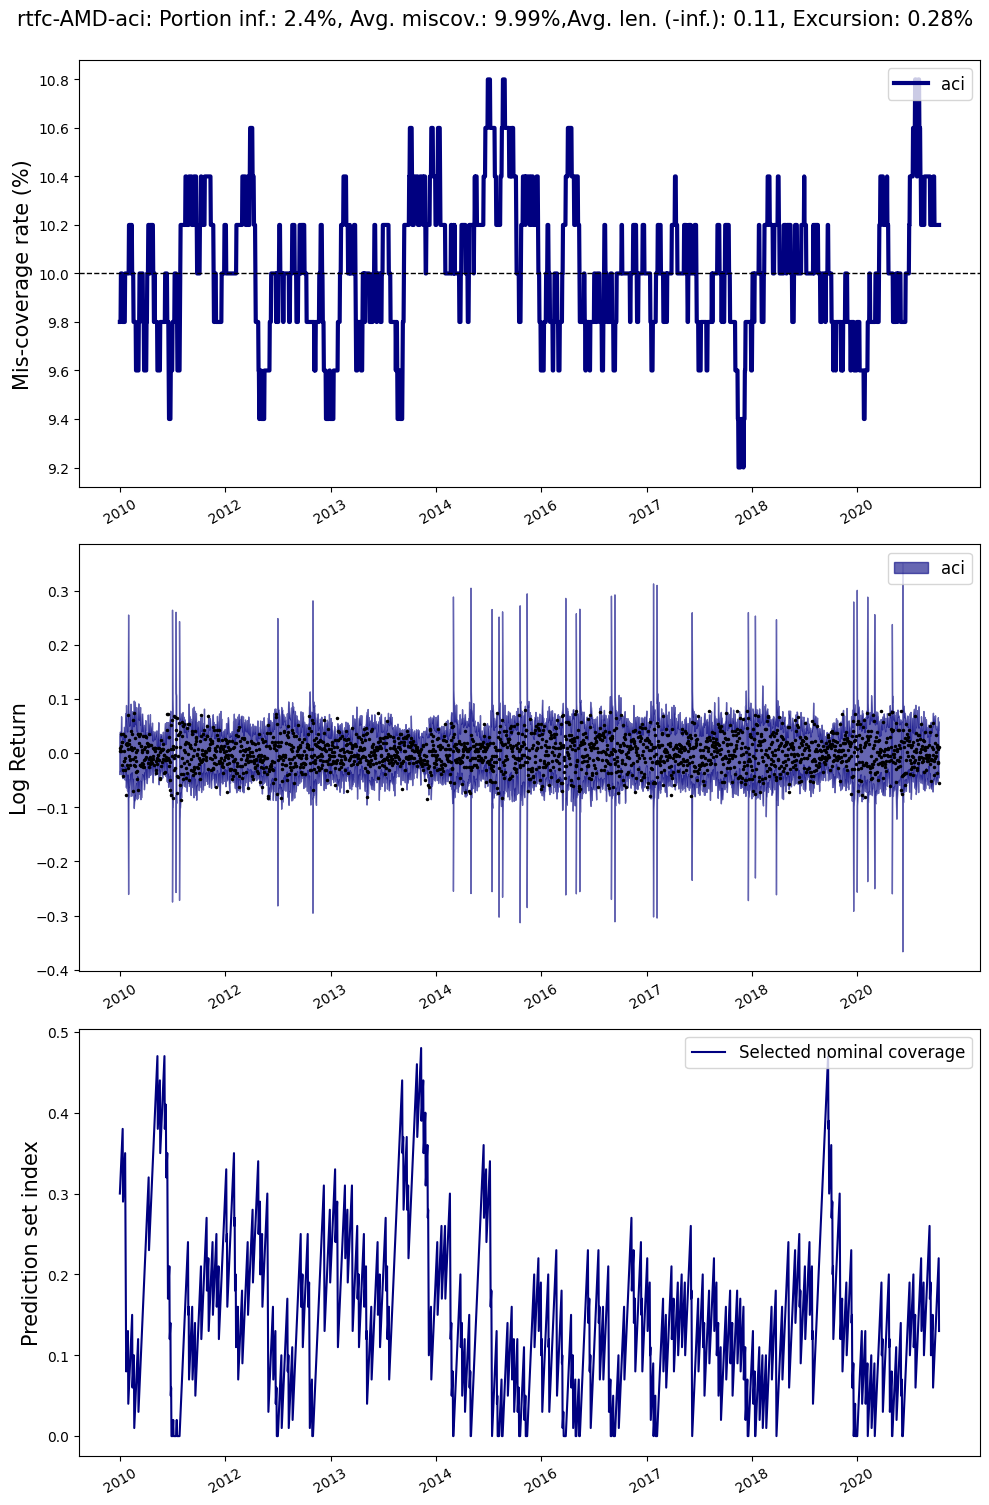

In [6]:
visualize_single_exp(exp.params, exp.result)

# Comparsion of three experiments

Next we demonstrate how to compare performance across three methods -- ACI, BCI, fixed $\alpha_t$ for the same experiment.

In [7]:
exp_aci = ForecastingExperiment(read_yaml('config/rtfc-aci-AMD.yaml'))
exp_aci.run()

exp_bci = ForecastingExperiment(read_yaml('config/rtfc-bci-AMD.yaml'))
exp_bci.run()

exp_fixed = ForecastingExperiment(read_yaml('config/rtfc-fixed-AMD.yaml'))
exp_fixed.run()

2026-03-02 11:56:34,027 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 STARTED
2026-03-02 11:56:36,575 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 ENDED in 2.5486810207366943s
2026-03-02 11:56:36,583 - INFO - Experiment rtfc-bci-AMD-gamma_0.8-lambda0_5.0 STARTED
2026-03-02 11:56:45,131 - INFO - Experiment rtfc-bci-AMD-gamma_0.8-lambda0_5.0 ENDED in 8.54807996749878s
2026-03-02 11:56:45,139 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA STARTED
2026-03-02 11:56:47,365 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA ENDED in 2.2262301445007324s


As before, we can visualize the comparsion as `visualize_three_exp`. In contrast to the previous plot, the figure first panel is the moving average mis-coverage rate, and the bottom panel is the moving average of interval length. The performance metric is given in the title of the plot:

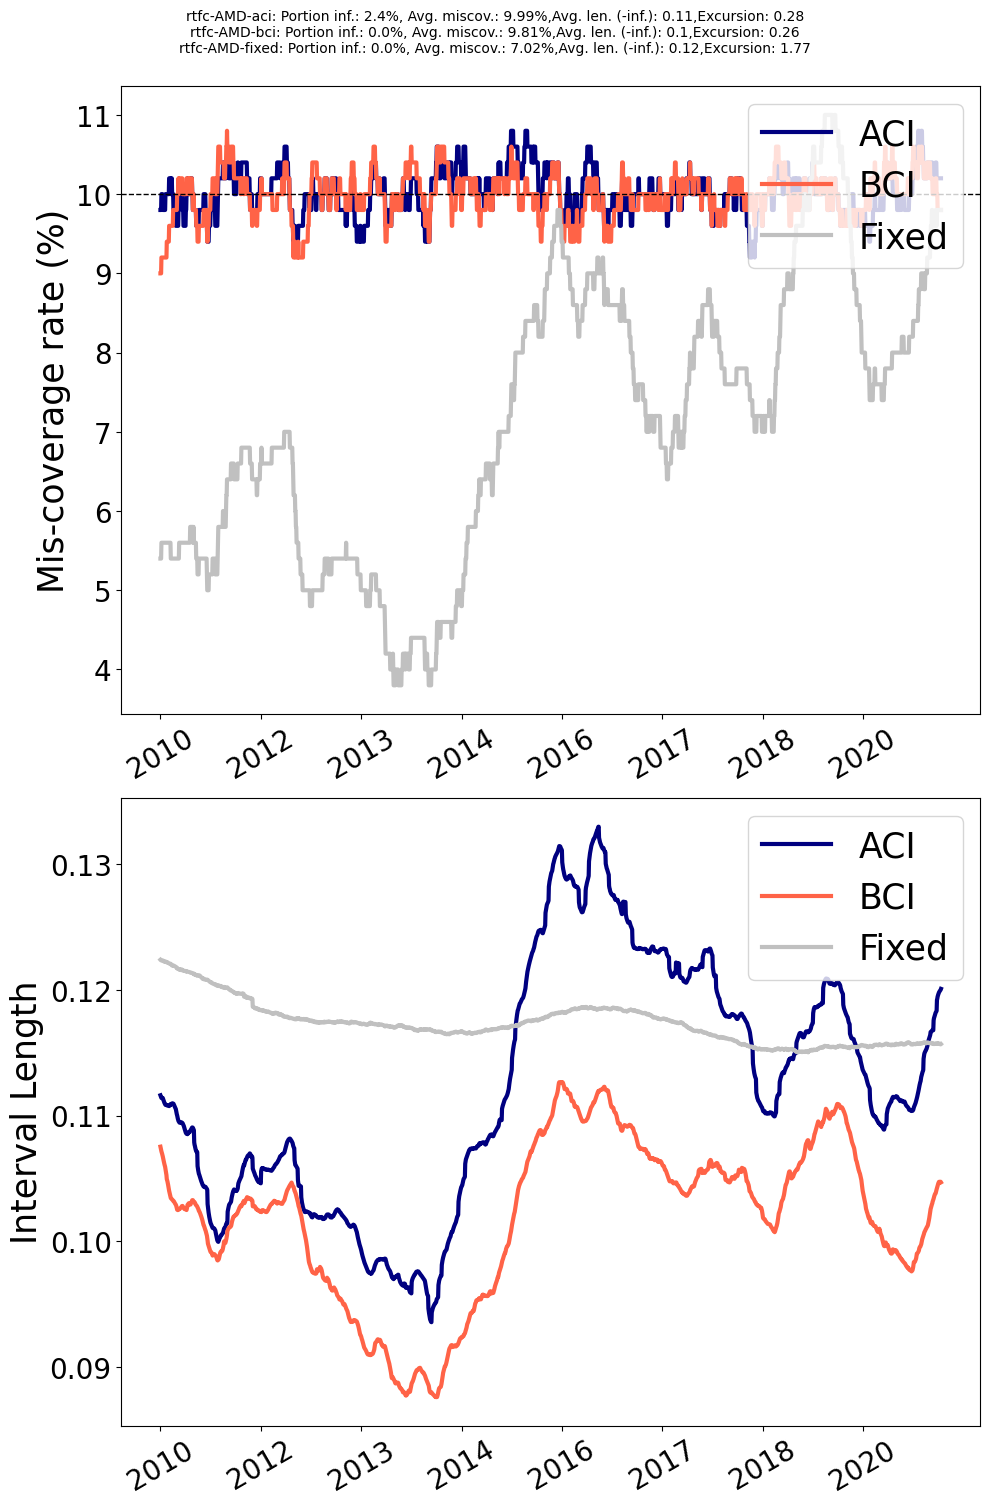

In [8]:
visualize_three_exp(exp_aci.params, exp_aci.result,
                    exp_bci.params, exp_bci.result,
                    exp_fixed.params, exp_fixed.result)

In [17]:
"""
RETURNS (rtfc): PID Targeting BCI Variance - ALL DATASETS
Runs Amazon, AMD, Nvidia in one script
BCI and PID run separately for each gamma
Binary search η in [0, 5B] where B = 99th percentile
Creates 4-line plots: ACI, BCI, Fixed, PID
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

sys.setrecursionlimit(10000)

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def compute_metrics(result_df):
    """Compute variance, miscoverage, length"""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce')
    beta = pd.to_numeric(result_df['beta'], errors='coerce')
    upper = pd.to_numeric(result_df['upper'], errors='coerce')
    lower = pd.to_numeric(result_df['lower'], errors='coerce')
    
    # Variance (alpha > beta)
    err_ind = (alpha > beta).astype(float)
    local_miscov = err_ind.rolling(window=50, min_periods=1).mean()
    var = local_miscov.var()
    
    # Miscoverage
    miscov = err_ind.mean()
    
    # Length
    raw_lengths = upper - lower
    valid_lengths = raw_lengths[np.isfinite(raw_lengths)]
    length = valid_lengths.mean() if len(valid_lengths) > 0 else 0.0
    
    return var, miscov, length


def run_pid_variance(scores, eta, csat, ki, y_pred_center, y_true):
    """Run PID and return variance"""
    try:
        pid_out = quantile_integrator_log(
            scores=scores, alpha=0.1, lr=eta,
            Csat=csat, KI=ki, ahead=1, T_burnin=100
        )
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        upper = y_pred_center + q
        lower = y_pred_center - q
        is_covered = (y_true >= lower) & (y_true <= upper)
        
        err_ind = (~is_covered).astype(float)
        var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
        
        return var, True, q
    except:
        return 1e10, False, None


def binary_search_5B(scores, y_pred_center, y_true, csat, ki, target_var):
    """Binary search in [0, 5B] to match target variance"""
    B = np.percentile(scores, 99)
    bound_5B = 5 * B
    
    low, high = 1e-6, bound_5B
    best_eta = low
    best_diff = 1e10
    best_q = None
    
    print(f"    Binary search [0, {bound_5B:.4f}]...", end=" ")
    
    for _ in range(25):
        mid = np.sqrt(low * high)
        var, valid, q = run_pid_variance(scores, mid, csat, ki, y_pred_center, y_true)
        
        if not valid:
            high = mid
            continue
        
        diff = abs(var - target_var)
        if diff < best_diff:
            best_diff = diff
            best_eta = mid
            best_q = q
        
        if var > target_var:
            low = mid
        else:
            high = mid
    
    status = "Hit 5B Bound" if abs(best_eta - bound_5B) < 1e-4 else "Interior"
    print(f"η={best_eta:.4f} ({status})")
    
    return best_eta, best_q, bound_5B


def create_pid_df(exp_fixed, pid_q):
    """Create PID result dataframe"""
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = y_pred_center + pid_q
    df_pid['lower'] = y_pred_center - pid_q
    df_pid['alpha'] = 0.1
    
    is_cov = (y_true >= df_pid['lower']) & (y_true <= df_pid['upper'])
    df_pid['beta'] = is_cov.astype(int)
    
    return df_pid


# =============================================================================
# MAIN SCRIPT
# =============================================================================

if __name__ == "__main__":
    datasets = ['Amazon', 'AMD', 'Nvidia']
    task = 'rtfc'
    gammas = [0.1, 0.008]
    
    for dataset in datasets:
        print(f"\n{'='*70}")
        print(f"{dataset.upper()} RETURNS: PID TARGETING BCI VARIANCE")
        print(f"BCI and PID run separately for each gamma")
        print(f"{'='*70}")
        
        # Load Fixed only once (doesn't change with gamma)
        print(f"\nLoading Fixed baseline...")
        exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{dataset}.yaml'))
        exp_fixed.run()
        
        fixed_var, fixed_miscov, fixed_len = compute_metrics(exp_fixed.result)
        
        # Prepare PID data (same for both gammas)
        y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
        upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
        lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
        y_pred_center = (upper + lower) / 2
        scores = np.abs(y_true - y_pred_center)
        
        T = len(scores)
        csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
        ki = np.percentile(scores, 99)
        
        print(f"K_I (99th %ile):       {ki:.4f}")
        
        # Loop through gammas - BCI and PID run for EACH gamma
        summary_data = []
        
        for gamma in gammas:
            print(f"\n{'-'*70}")
            print(f"γ = {gamma}")
            print(f"{'-'*70}")
            
            # Load ACI with this gamma
            print(f"  Loading ACI...")
            aci_config = read_yaml(f'config/{task}-aci-{dataset}.yaml')
            aci_config['gamma'] = gamma
            exp_aci = ForecastingExperiment(aci_config)
            exp_aci.run()
            
            # Load BCI and adjust parameters based on gamma
            print(f"  Loading BCI...")
            bci_config = read_yaml(f'config/{task}-bci-{dataset}.yaml')
            
            print(f"    BEFORE: gamma={bci_config['gamma']}, lambda_init={bci_config['lambda_init']}")
            
            # Scale BCI parameters for loose control (ratio: 0.1/0.008 = 12.5)
            if gamma == 0.008:
                bci_config['gamma'] = bci_config['gamma'] / 12.5
                bci_config['lambda_init'] = bci_config['lambda_init'] / 12.5
                print(f"    AFTER adjustment: gamma={bci_config['gamma']:.1f}, lambda_init={bci_config['lambda_init']:.1f}")
            
            exp_bci = ForecastingExperiment(bci_config)
            exp_bci.run()
            
            # Print BCI variance to confirm it changed
            bci_var_check = compute_metrics(exp_bci.result)
            print(f"    BCI variance: {bci_var_check[0]:.2e}")
            
            # Get metrics
            aci_var, aci_miscov, aci_len = compute_metrics(exp_aci.result)
            bci_var, bci_miscov, bci_len = compute_metrics(exp_bci.result)
            
            print(f"  BCI Variance (TARGET): {bci_var:.2e}")
            print(f"  ACI Variance (ref):    {aci_var:.2e}")
            
            # Binary search for PID targeting THIS BCI variance
            eta_found, pid_q, bound_5B = binary_search_5B(scores, y_pred_center, y_true, 
                                                           csat, ki, bci_var)
            
            # Create PID dataframe
            pid_df = create_pid_df(exp_fixed, pid_q)
            pid_var, pid_miscov, pid_len = compute_metrics(pid_df)
            
            print(f"  PID Variance achieved: {pid_var:.2e} (error: {abs(pid_var-bci_var)/bci_var*100:.1f}%)")
            print(f"  Bound (5B):            {bound_5B:.4f}")
            
            # Print summary table
            print(f"\n  SUMMARY TABLE:")
            print(f"  {'Method':<10} | {'Variance':<12} | {'Var vs BCI':<12} | {'Miscov(%)':<10} | {'Length':<10} | {'Len vs BCI':<12}")
            print(f"  {'-'*85}")
            print(f"  {'ACI':<10} | {aci_var:<12.2e} | {(aci_var/bci_var-1)*100:>11.1f}% | {aci_miscov*100:<10.2f} | {aci_len:<10.4f} | {(aci_len/bci_len-1)*100:>11.1f}%")
            print(f"  {'BCI':<10} | {bci_var:<12.2e} | {'0.0%':>12} | {bci_miscov*100:<10.2f} | {bci_len:<10.4f} | {'0.0%':>12}")
            print(f"  {'Fixed':<10} | {fixed_var:<12.2e} | {(fixed_var/bci_var-1)*100:>11.1f}% | {fixed_miscov*100:<10.2f} | {fixed_len:<10.4f} | {(fixed_len/bci_len-1)*100:>11.1f}%")
            print(f"  {'PID':<10} | {pid_var:<12.2e} | {(pid_var/bci_var-1)*100:>11.1f}% | {pid_miscov*100:<10.2f} | {pid_len:<10.4f} | {(pid_len/bci_len-1)*100:>11.1f}%")
            print(f"  {'-'*85}")
            
            # Create 4-line plot
            print(f"  Creating visualization...")
            
            fig, axs = plt.subplots(2, 1, figsize=(10, 15))
            
            def clean_df(df):
                df['upper'] = pd.to_numeric(df['upper'], errors='coerce')
                df['lower'] = pd.to_numeric(df['lower'], errors='coerce')
                df['true_y'] = pd.to_numeric(df['true_y'], errors='coerce')
                return df
            
            ma_window = 250
            skip = 300
            xform = lambda x: x
            
            p_aci = gen_plot_data(clean_df(exp_aci.result), ma_window, skip, xform)
            p_bci = gen_plot_data(clean_df(exp_bci.result), ma_window, skip, xform)
            p_fix = gen_plot_data(clean_df(exp_fixed.result), ma_window, skip, xform)
            p_pid = gen_plot_data(clean_df(pid_df), ma_window, skip, xform)
            
            # Panel 1: Miscoverage
            axs[0].plot(100*p_aci['miscovrate'], color='navy', label='ACI', linewidth=3)
            axs[0].plot(100*p_bci['miscovrate'], color='tomato', label='BCI (Target)', linewidth=3)
            axs[0].plot(100*p_fix['miscovrate'], color='silver', label='Fixed', linewidth=3)
            axs[0].plot(100*p_pid['miscovrate'], color='green', linestyle='--', 
                        label=f'PID (η={eta_found:.4f})', linewidth=3)
            axs[0].axhline(10, color='black', linestyle='--')
            axs[0].set_ylabel('Mis-coverage rate (%)', fontsize=25)
            axs[0].legend(loc='upper right', prop={'size': 20})
            axs[0].set_xticks(p_aci['indices'])
            axs[0].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30, fontsize=20)
            
            for label in axs[0].get_yticklabels():
                label.set_fontsize(20)
            
            # Panel 2: Length
            axs[1].plot(p_aci['length'], color='navy', label='ACI', linewidth=3)
            axs[1].plot(p_bci['length'], color='tomato', label='BCI', linewidth=3)
            axs[1].plot(p_fix['length'], color='silver', label='Fixed', linewidth=3)
            axs[1].plot(p_pid['length'], color='green', label='PID', linewidth=3)
            axs[1].set_ylabel('Interval Length', fontsize=25)
            axs[1].legend(loc='upper right', prop={'size': 20})
            axs[1].set_xticks(p_aci['indices'])
            axs[1].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30, fontsize=20)
            
            for label in axs[1].get_yticklabels():
                label.set_fontsize(20)
            
            fig.suptitle(f'Return forecasting for {dataset} (γ={gamma})', fontsize=30, y=1.0005)
            plt.tight_layout()
            
            filename = f'{dataset}_{task}_gamma{gamma}_PID_BCI_target.png'
            plt.savefig(filename, dpi=300)
            print(f"  ✓ Saved: {filename}")
            plt.close()
            
            # Collect summary
            summary_data.append({
                'gamma': gamma,
                'eta': eta_found,
                'bound_5B': bound_5B,
                'bci_var': bci_var,
                'pid_var': pid_var,
                'var_ratio': pid_var / bci_var,
                'bci_miscov': bci_miscov * 100,
                'pid_miscov': pid_miscov * 100,
                'bci_length': bci_len,
                'pid_length': pid_len
            })
        
        # Final summary for this dataset
        print(f"\n{'='*70}")
        print(f"FINAL SUMMARY - {dataset}")
        print(f"{'='*70}")
        print(f"\n{'Gamma':<8} {'Eta':<10} {'Var (BCI)':<12} {'Var (PID)':<12} {'Var Ratio':<12} "
              f"{'Miscov BCI':<12} {'Miscov PID':<12} {'Length BCI':<12} {'Length PID':<12}")
        print("-" * 120)
        
        for row in summary_data:
            print(f"{row['gamma']:<8.3f} {row['eta']:<10.4f} {row['bci_var']:<12.2e} "
                  f"{row['pid_var']:<12.2e} {row['var_ratio']:<12.3f} "
                  f"{row['bci_miscov']:<12.2f} {row['pid_miscov']:<12.2f} "
                  f"{row['bci_length']:<12.4f} {row['pid_length']:<12.4f}")
        
        print(f"\n{'='*70}")
    
    print(f"\n\n{'='*70}")
    print("ALL DATASETS DONE!")
    print(f"{'='*70}")

2026-03-02 12:08:48,698 - INFO - Experiment rtfc-fixed-Amazon-gamma_NA-lambda0_NA STARTED



AMAZON RETURNS: PID TARGETING BCI VARIANCE
BCI and PID run separately for each gamma

Loading Fixed baseline...


2026-03-02 12:08:51,817 - INFO - Experiment rtfc-fixed-Amazon-gamma_NA-lambda0_NA ENDED in 3.1182661056518555s
2026-03-02 12:08:51,831 - INFO - Experiment rtfc-aci-Amazon-gamma_0.1-lambda0_0.9 STARTED


K_I (99th %ile):       0.0668

----------------------------------------------------------------------
γ = 0.1
----------------------------------------------------------------------
  Loading ACI...


2026-03-02 12:08:55,090 - INFO - Experiment rtfc-aci-Amazon-gamma_0.1-lambda0_0.9 ENDED in 3.2596421241760254s
2026-03-02 12:08:55,100 - INFO - Experiment rtfc-bci-Amazon-gamma_0.8-lambda0_5.0 STARTED


...

  Loading BCI...
    BEFORE: gamma=0.4, lambda_init=1.0
    AFTER adjustment: gamma=0.0, lambda_init=0.1


2026-03-02 12:10:17,917 - INFO - Experiment rtfc-bci-Nvidia-gamma_0.032-lambda0_0.08 ENDED in 8.64710807800293s


    BCI variance: 9.50e-03
  BCI Variance (TARGET): 9.50e-03
  ACI Variance (ref):    3.79e-03
    Binary search [0, 0.3550]... 

100%|██████████| 3058/3058 [00:00<00:00, 174365.91it/s]


η=0.0000 (Interior)
  PID Variance achieved: 4.91e-03 (error: 48.3%)
  Bound (5B):            0.3550

  SUMMARY TABLE:
  Method     | Variance     | Var vs BCI   | Miscov(%)  | Length     | Len vs BCI  
  -------------------------------------------------------------------------------------
  ACI        | 3.79e-03     |       -60.1% | 9.97       | 0.0906     |        10.6%
  BCI        | 9.50e-03     |         0.0% | 11.12      | 0.0819     |         0.0%
  Fixed      | 5.40e-03     |       -43.2% | 6.87       | 0.1024     |        25.0%
  PID        | 4.91e-03     |       -48.3% | 14.06      | 0.0788     |        -3.7%
  -------------------------------------------------------------------------------------
  Creating visualization...
  ✓ Saved: Nvidia_rtfc_gamma0.008_PID_BCI_target.png

FINAL SUMMARY - Nvidia

Gamma    Eta        Var (BCI)    Var (PID)    Var Ratio    Miscov BCI   Miscov PID   Length BCI   Length PID  
--------------------------------------------------------------------

In [18]:
"""
VOLATILITY (vlfc): PID Targeting BCI Variance - ALL DATASETS
Runs Amazon, AMD, Nvidia in one script
BCI parameters scale with gamma
Works in sqrt-transformed space
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

sys.setrecursionlimit(10000)

def compute_metrics(result_df):
    """Compute metrics in sqrt-transformed space"""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce')
    beta = pd.to_numeric(result_df['beta'], errors='coerce')
    upper = pd.to_numeric(result_df['upper'], errors='coerce')
    lower = pd.to_numeric(result_df['lower'], errors='coerce')
    
    err_ind = (alpha > beta).astype(float)
    local_miscov = err_ind.rolling(window=50, min_periods=1).mean()
    var = local_miscov.var()
    miscov = err_ind.mean()
    
    # Length in sqrt space
    safe_upper = np.maximum(upper, 0)
    safe_lower = np.maximum(lower, 0)
    raw_lengths = np.sqrt(safe_upper) - np.sqrt(safe_lower)
    valid_lengths = raw_lengths[np.isfinite(raw_lengths)]
    length = valid_lengths.mean() if len(valid_lengths) > 0 else 0.0
    
    return var, miscov, length

def run_pid_variance(scores_sqrt, eta, csat, ki, y_pred_center_sqrt, y_true_sqrt):
    """Run PID in sqrt space"""
    try:
        pid_out = quantile_integrator_log(
            scores=scores_sqrt, alpha=0.1, lr=eta,
            Csat=csat, KI=ki, ahead=1, T_burnin=100
        )
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        upper_sqrt = y_pred_center_sqrt + q
        lower_sqrt = np.maximum(y_pred_center_sqrt - q, 0)
        is_covered = (y_true_sqrt >= lower_sqrt) & (y_true_sqrt <= upper_sqrt)
        
        err_ind = (~is_covered).astype(float)
        var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
        
        upper_orig = upper_sqrt ** 2
        lower_orig = lower_sqrt ** 2
        
        return var, True, (q, upper_orig, lower_orig)
    except:
        return 1e10, False, None

def binary_search_5B(scores_sqrt, y_pred_center_sqrt, y_true_sqrt, csat, ki, target_var):
    """Binary search in [0, 5B]"""
    B = np.percentile(scores_sqrt, 99)
    bound_5B = 5 * B
    
    low, high = 1e-6, bound_5B
    best_eta = low
    best_diff = 1e10
    best_result = None
    
    print(f"    Binary search [0, {bound_5B:.4f}]...", end=" ")
    
    for _ in range(30):
        mid = np.sqrt(low * high)
        var, valid, result = run_pid_variance(scores_sqrt, mid, csat, ki, 
                                               y_pred_center_sqrt, y_true_sqrt)
        
        if not valid:
            high = mid
            continue
        
        diff = abs(var - target_var)
        if diff < best_diff:
            best_diff = diff
            best_eta = mid
            best_result = result
        
        if var > target_var:
            low = mid
        else:
            high = mid
    
    status = "Hit 5B Bound" if abs(best_eta - bound_5B) < 1e-4 else "Interior"
    print(f"η={best_eta:.4f} ({status})")
    
    if best_result is None:
        return None, None, None, bound_5B
    
    pid_q, upper_orig, lower_orig = best_result
    return best_eta, pid_q, (upper_orig, lower_orig), bound_5B

def create_pid_df(exp_fixed, pid_intervals):
    """Create PID dataframe"""
    upper_orig, lower_orig = pid_intervals
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = upper_orig
    df_pid['lower'] = lower_orig
    df_pid['alpha'] = 0.1
    
    is_cov = (y_true >= lower_orig) & (y_true <= upper_orig)
    df_pid['beta'] = is_cov.astype(int)
    
    return df_pid

if __name__ == "__main__":
    datasets = ['Amazon', 'AMD', 'Nvidia']
    task = 'vlfc'
    gammas = [0.1, 0.008]
    
    for dataset in datasets:
        print(f"\n{'='*70}")
        print(f"{dataset.upper()} VOLATILITY: PID TARGETING BCI VARIANCE")
        print(f"BCI parameters scale with gamma")
        print(f"{'='*70}")
        
        # Load Fixed once
        print(f"\nLoading Fixed baseline...")
        exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{dataset}.yaml'))
        exp_fixed.run()
        
        fixed_var, fixed_miscov, fixed_len = compute_metrics(exp_fixed.result)
        
        # Prepare data in sqrt space
        y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
        upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
        lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
        
        y_true_sqrt = np.sqrt(np.maximum(y_true, 0))
        upper_sqrt = np.sqrt(np.maximum(upper, 0))
        lower_sqrt = np.sqrt(np.maximum(lower, 0))
        y_pred_center_sqrt = (upper_sqrt + lower_sqrt) / 2
        scores_sqrt = np.abs(y_true_sqrt - y_pred_center_sqrt)
        
        T = len(scores_sqrt)
        csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
        ki = np.percentile(scores_sqrt, 99)
        
        print(f"K_I (99th %ile, √):    {ki:.4f}")
        
        # Loop through gammas
        summary_data = []
        
        for gamma in gammas:
            print(f"\n{'-'*70}")
            print(f"γ = {gamma}")
            print(f"{'-'*70}")
            
            # Load ACI
            print(f"  Loading ACI...")
            aci_config = read_yaml(f'config/{task}-aci-{dataset}.yaml')
            aci_config['gamma'] = gamma
            exp_aci = ForecastingExperiment(aci_config)
            exp_aci.run()
            
            # Load BCI and scale parameters
            print(f"  Loading BCI...")
            bci_config = read_yaml(f'config/{task}-bci-{dataset}.yaml')
            
            print(f"    BEFORE: gamma={bci_config['gamma']}, lambda_init={bci_config['lambda_init']}")
            
            if gamma == 0.008:
                bci_config['gamma'] = bci_config['gamma'] / 12.5
                bci_config['lambda_init'] = bci_config['lambda_init'] / 12.5
                print(f"    AFTER: gamma={bci_config['gamma']:.3f}, lambda_init={bci_config['lambda_init']:.3f}")
            
            exp_bci = ForecastingExperiment(bci_config)
            exp_bci.run()
            
            # Get metrics
            aci_var, aci_miscov, aci_len = compute_metrics(exp_aci.result)
            bci_var, bci_miscov, bci_len = compute_metrics(exp_bci.result)
            
            print(f"  BCI Variance (TARGET): {bci_var:.2e}")
            print(f"  ACI Variance (ref):    {aci_var:.2e}")
            
            # Binary search PID
            result = binary_search_5B(scores_sqrt, y_pred_center_sqrt, y_true_sqrt, 
                                      csat, ki, bci_var)
            
            if result[0] is None:
                print(f"  ✗ Binary search failed")
                continue
            
            eta_found, pid_q, pid_intervals, bound_5B = result
            
            # Create PID dataframe
            pid_df = create_pid_df(exp_fixed, pid_intervals)
            pid_var, pid_miscov, pid_len = compute_metrics(pid_df)
            
            print(f"  PID Variance achieved: {pid_var:.2e} (error: {abs(pid_var-bci_var)/bci_var*100:.1f}%)")
            print(f"  Bound (5B):            {bound_5B:.4f}")
            
            # Summary table
            print(f"\n  SUMMARY TABLE:")
            print(f"  {'Method':<10} | {'Variance':<12} | {'Var vs BCI':<12} | {'Miscov(%)':<10} | {'Length(√)':<10} | {'Len vs BCI':<12}")
            print(f"  {'-'*90}")
            print(f"  {'ACI':<10} | {aci_var:<12.2e} | {(aci_var/bci_var-1)*100:>11.1f}% | {aci_miscov*100:<10.2f} | {aci_len:<10.4f} | {(aci_len/bci_len-1)*100:>11.1f}%")
            print(f"  {'BCI':<10} | {bci_var:<12.2e} | {'0.0%':>12} | {bci_miscov*100:<10.2f} | {bci_len:<10.4f} | {'0.0%':>12}")
            print(f"  {'Fixed':<10} | {fixed_var:<12.2e} | {(fixed_var/bci_var-1)*100:>11.1f}% | {fixed_miscov*100:<10.2f} | {fixed_len:<10.4f} | {(fixed_len/bci_len-1)*100:>11.1f}%")
            print(f"  {'PID':<10} | {pid_var:<12.2e} | {(pid_var/bci_var-1)*100:>11.1f}% | {pid_miscov*100:<10.2f} | {pid_len:<10.4f} | {(pid_len/bci_len-1)*100:>11.1f}%")
            print(f"  {'-'*90}")
            
            # Visualization
            print(f"  Creating visualization...")
            fig, axs = plt.subplots(2, 1, figsize=(10, 15))
            
            def clean_df(df):
                for col in ['upper', 'lower', 'true_y']:
                    if col in df.columns:
                        df[col] = pd.to_numeric(df[col], errors='coerce')
                return df
            
            ma_window = 250
            skip = 500
            xform = lambda x: np.sqrt(np.maximum(x, 0))
            
            p_aci = gen_plot_data(clean_df(exp_aci.result.copy()), ma_window, skip, xform)
            p_bci = gen_plot_data(clean_df(exp_bci.result.copy()), ma_window, skip, xform)
            p_fix = gen_plot_data(clean_df(exp_fixed.result.copy()), ma_window, skip, xform)
            p_pid = gen_plot_data(clean_df(pid_df.copy()), ma_window, skip, xform)
            
            # Panel 1
            axs[0].plot(100*p_aci['miscovrate'], color='navy', label='ACI', linewidth=3)
            axs[0].plot(100*p_bci['miscovrate'], color='tomato', label='BCI (Target)', linewidth=3)
            axs[0].plot(100*p_fix['miscovrate'], color='silver', label='Fixed', linewidth=3)
            axs[0].plot(100*p_pid['miscovrate'], color='green', linestyle='--', 
                        label=f'PID (η={eta_found:.4f})', linewidth=3)
            axs[0].axhline(10, color='black', linestyle='--')
            axs[0].set_ylabel('Mis-coverage rate (%)', fontsize=25)
            axs[0].legend(loc='upper right', prop={'size': 20})
            axs[0].set_xticks(p_aci['indices'])
            axs[0].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30, fontsize=20)
            
            for label in axs[0].get_yticklabels():
                label.set_fontsize(20)
            
            # Panel 2
            axs[1].plot(p_aci['length'], color='navy', label='ACI', linewidth=3)
            axs[1].plot(p_bci['length'], color='tomato', label='BCI', linewidth=3)
            axs[1].plot(p_fix['length'], color='silver', label='Fixed', linewidth=3)
            axs[1].plot(p_pid['length'], color='green', label='PID', linewidth=3)
            axs[1].set_ylabel('Interval Length', fontsize=25)
            axs[1].legend(loc='upper right', prop={'size': 20})
            axs[1].set_xticks(p_aci['indices'])
            axs[1].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30, fontsize=20)
            
            for label in axs[1].get_yticklabels():
                label.set_fontsize(20)
            
            fig.suptitle(f'Volatility forecasting for {dataset} (γ={gamma})', fontsize=30, y=1.0005)
            plt.tight_layout()
            
            filename = f'{dataset}_{task}_gamma{gamma}_PID_BCI_target.png'
            plt.savefig(filename, dpi=300)
            print(f"  ✓ Saved: {filename}")
            plt.close()
            
            # Collect summary
            summary_data.append({
                'gamma': gamma,
                'eta': eta_found,
                'bound_5B': bound_5B,
                'bci_var': bci_var,
                'pid_var': pid_var,
                'var_ratio': pid_var / bci_var,
                'bci_miscov': bci_miscov * 100,
                'pid_miscov': pid_miscov * 100,
                'bci_length': bci_len,
                'pid_length': pid_len
            })
        
        # Final summary for this dataset
        print(f"\n{'='*70}")
        print(f"FINAL SUMMARY - {dataset}")
        print(f"{'='*70}")
        print(f"\n{'Gamma':<8} {'Eta':<10} {'Var (BCI)':<12} {'Var (PID)':<12} {'Var Ratio':<12} "
              f"{'Miscov BCI':<12} {'Miscov PID':<12} {'Length BCI':<12} {'Length PID':<12}")
        print("-" * 120)
        
        for row in summary_data:
            print(f"{row['gamma']:<8.3f} {row['eta']:<10.4f} {row['bci_var']:<12.2e} "
                  f"{row['pid_var']:<12.2e} {row['var_ratio']:<12.3f} "
                  f"{row['bci_miscov']:<12.2f} {row['pid_miscov']:<12.2f} "
                  f"{row['bci_length']:<12.4f} {row['pid_length']:<12.4f}")
        
        print(f"\n{'='*70}")
    
    print(f"\n\n{'='*70}")
    print("ALL DATASETS DONE!")
    print(f"{'='*70}")

2026-03-02 12:19:54,935 - INFO - Experiment vlfc-fixed-Amazon-gamma_NA-lambda0_NA STARTED



AMAZON VOLATILITY: PID TARGETING BCI VARIANCE
BCI parameters scale with gamma

Loading Fixed baseline...


2026-03-02 12:20:00,188 - INFO - Experiment vlfc-fixed-Amazon-gamma_NA-lambda0_NA ENDED in 5.252989768981934s
2026-03-02 12:20:00,203 - INFO - Experiment vlfc-aci-Amazon-gamma_0.1-lambda0_0.9 STARTED


K_I (99th %ile, √):    9.6848

----------------------------------------------------------------------
γ = 0.1
----------------------------------------------------------------------
  Loading ACI...


2026-03-02 12:20:05,517 - INFO - Experiment vlfc-aci-Amazon-gamma_0.1-lambda0_0.9 ENDED in 5.314053058624268s
2026-03-02 12:20:05,529 - INFO - Experiment vlfc-bci-Amazon-gamma_490-lambda0_800 STARTED


...

  Loading BCI...
    BEFORE: gamma=490.0, lambda_init=800.0
    AFTER: gamma=39.200, lambda_init=64.000


2026-03-02 12:23:55,010 - INFO - Experiment vlfc-bci-Nvidia-gamma_39.2-lambda0_64.0 ENDED in 28.006619930267334s


  BCI Variance (TARGET): 6.87e-03
  ACI Variance (ref):    1.44e-03
    Binary search [0, 39.2299]... 

100%|██████████| 5644/5644 [00:00<00:00, 190247.22it/s]


η=0.0090 (Interior)
  PID Variance achieved: 6.87e-03 (error: 0.1%)
  Bound (5B):            39.2299

  SUMMARY TABLE:
  Method     | Variance     | Var vs BCI   | Miscov(%)  | Length(√)  | Len vs BCI  
  ------------------------------------------------------------------------------------------
  ACI        | 1.44e-03     |       -79.1% | 10.01      | 6.4753     |         4.9%
  BCI        | 6.87e-03     |         0.0% | 10.49      | 6.1717     |         0.0%
  Fixed      | 2.23e-03     |       -67.5% | 12.17      | 6.0832     |        -1.4%
  PID        | 6.87e-03     |        -0.1% | 10.13      | 6.3251     |         2.5%
  ------------------------------------------------------------------------------------------
  Creating visualization...
  ✓ Saved: Nvidia_vlfc_gamma0.008_PID_BCI_target.png

FINAL SUMMARY - Nvidia

Gamma    Eta        Var (BCI)    Var (PID)    Var Ratio    Miscov BCI   Miscov PID   Length BCI   Length PID  
----------------------------------------------------------

In [7]:
"""
GOOGLE TRENDS: BCI and PID Target ACI Variance
- BCI: Binary search on gamma (lambda_init=10000) to match ACI variance
- PID: Binary search on eta to match ACI variance
- All methods naturally hit ~10% miscoverage (because alpha=0.1)
- Goal: Show BCI has shorter intervals than ACI/PID despite matching variance
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

sys.setrecursionlimit(10000)

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def clean_config(config):
    """Ensures all list parameters from YAML become single floats/ints."""
    new_config = config.copy()
    for key, value in new_config.items():
        if isinstance(value, list):
            new_config[key] = value[0]
    return new_config

def compute_metrics(result_df):
    """Compute variance, mean miscoverage, and mean interval length with burn-in."""
    if result_df is None:
        return 1e10, 0.0, 0.0
    
    # Exclude first 100 points to ignore initial spikes
    df = result_df.iloc[100:].copy()
    
    alpha = pd.to_numeric(df['alpha'], errors='coerce')
    beta = pd.to_numeric(df['beta'], errors='coerce')
    upper = pd.to_numeric(df['upper'], errors='coerce')
    lower = pd.to_numeric(df['lower'], errors='coerce')
    
    err_ind = (alpha > beta).astype(float)
    local_miscov = err_ind.rolling(window=50, min_periods=1).mean()
    
    var = local_miscov.var()
    miscov = err_ind.mean()
    
    raw_lengths = upper - lower
    valid_lengths = raw_lengths[np.isfinite(raw_lengths)]
    length = valid_lengths.mean() if len(valid_lengths) > 0 else 0.0
    
    return var, miscov, length

# =============================================================================
# BCI SEARCH - ONLY VARIANCE MATCHING
# =============================================================================

def run_bci_with_gamma(gamma_value, base_config):
    """Run BCI with specific gamma and cleaned parameters."""
    try:
        config = base_config.copy()
        config = clean_config(config)
        config['gamma'] = float(gamma_value)
        
        exp = ForecastingExperiment(config)
        exp.run()
        return exp.result
    except Exception:
        return None

def binary_search_bci_gamma(base_config, target_var):
    """Search for BCI gamma that matches ACI variance (no miscoverage targeting!)"""
    low, high = 1.0, 5000.0  # Reasonable range
    best_gamma = low
    best_diff = float('inf')
    best_result = None
    
    print(f"    Binary searching BCI gamma to match variance...", end=" ")
    for _ in range(30):
        mid = np.sqrt(low * high)
        res = run_bci_with_gamma(mid, base_config)
        if res is None:
            high = mid
            continue
            
        var, miscov, _ = compute_metrics(res)
        diff = abs(var - target_var)
        
        if diff < best_diff:
            best_diff = diff
            best_gamma = mid
            best_result = res
            
        # ONLY optimize for variance matching
        if var > target_var:
            low = mid
        else:
            high = mid
                
    print(f"γ_BCI={best_gamma:.2f}")
    return best_gamma, best_result

# =============================================================================
# PID SEARCH - ONLY VARIANCE MATCHING
# =============================================================================

def run_pid_metrics(scores, eta, csat, ki, y_pred_center, y_true):
    """Run PID and calculate metrics."""
    try:
        pid_out = quantile_integrator_log(
            scores=scores, alpha=0.1, lr=eta,
            Csat=csat, KI=ki, ahead=1, T_burnin=100
        )
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        df = pd.DataFrame({
            'upper': y_pred_center + q,
            'lower': y_pred_center - q,
            'alpha': 0.1,
            'true_y': y_true
        })
        df['beta'] = ((y_true >= df['lower']) & (y_true <= df['upper'])).astype(int)
        
        var, miscov, length = compute_metrics(df)
        return var, miscov, q
    except Exception:
        return 1e10, 0.0, None

def binary_search_pid_eta(scores, y_pred_center, y_true, csat, ki, target_var):
    """Search for PID eta that matches target variance (no miscoverage targeting!)"""
    B = np.percentile(scores, 99)
    bound_5B = 5 * B
    
    low, high = 1e-6, bound_5B
    best_eta = low
    best_diff = float('inf')
    best_q = None
    
    print(f"    Binary searching PID eta to match variance [0, {bound_5B:.4f}]...", end=" ")
    for _ in range(30):
        mid = np.sqrt(low * high)
        var, miscov, q = run_pid_metrics(scores, mid, csat, ki, y_pred_center, y_true)
        if q is None:
            high = mid
            continue
        
        diff = abs(var - target_var)
        if diff < best_diff:
            best_diff = diff
            best_eta = mid
            best_q = q
            
        # ONLY optimize for variance matching
        if var > target_var:
            low = mid
        else:
            high = mid
    
    print(f"η={best_eta:.4f}")
    return best_eta, best_q

# =============================================================================
# MAIN SCRIPT
# =============================================================================

if __name__ == "__main__":
    dataset, task = 'google_trends', 'trend'
    target_gamma_aci = 0.1 
    
    print(f"\n{'='*70}")
    print(f"GOOGLE TRENDS: VARIANCE-MATCHED COMPARISON")
    print(f"Goal: All methods match variance, compare interval lengths")
    print(f"{'='*70}")
    
    # 1. Load Fixed
    print(f"\nLoading Fixed baseline...")
    fixed_config = clean_config(read_yaml(f'config/{task}-fixed.yaml'))
    fixed_config['id'] = dataset
    exp_fixed = ForecastingExperiment(fixed_config)
    exp_fixed.run()
    fixed_v, fixed_m, fixed_l = compute_metrics(exp_fixed.result)
    
    # 2. Load ACI (this is the TARGET variance)
    print(f"\nLoading ACI (γ={target_gamma_aci})...")
    aci_config = clean_config(read_yaml(f'config/{task}-aci.yaml'))
    aci_config['id'], aci_config['gamma'] = dataset, target_gamma_aci
    exp_aci = ForecastingExperiment(aci_config)
    exp_aci.run()
    target_var, aci_m, aci_l = compute_metrics(exp_aci.result)
    print(f"  ACI Variance (TARGET): {target_var:.2e}")
    print(f"  ACI Miscoverage: {aci_m*100:.2f}%")
    print(f"  ACI Avg Length: {aci_l:.4f}")
    
    # 3. Match BCI to ACI Variance
    print(f"\nMatching BCI to ACI variance...")
    bci_base_config = read_yaml(f'config/{task}-bci.yaml')
    bci_base_config['id'], bci_base_config['lambda_init'] = dataset, 10000.0
    gamma_bci_found, bci_result = binary_search_bci_gamma(bci_base_config, target_var)
    bci_v, bci_m, bci_l = compute_metrics(bci_result)
    print(f"  BCI Variance: {bci_v:.2e} (error: {abs(bci_v-target_var)/target_var*100:.1f}%)")
    print(f"  BCI Miscoverage: {bci_m*100:.2f}%")
    print(f"  BCI Avg Length: {bci_l:.4f}")
    
    # 4. Match PID to ACI Variance
    print(f"\nMatching PID to ACI variance...")
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    u_f = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    l_f = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_center = (u_f + l_f) / 2
    scores = np.abs(y_true - y_center)
    
    T_len = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T_len) * 0.05) - 1 / np.log(T_len)), 0.1)
    ki = np.percentile(scores, 99)
    
    eta_found, pid_q = binary_search_pid_eta(scores, y_center, y_true, csat, ki, target_var)
    
    # Create final PID DataFrame
    df_pid = exp_fixed.result.copy()
    df_pid['upper'], df_pid['lower'] = y_center + pid_q, y_center - pid_q
    df_pid['alpha'], df_pid['beta'] = 0.1, ((y_true >= (y_center - pid_q)) & (y_true <= (y_center + pid_q))).astype(int)
    pid_v, pid_m, pid_l = compute_metrics(df_pid)
    print(f"  PID Variance: {pid_v:.2e} (error: {abs(pid_v-target_var)/target_var*100:.1f}%)")
    print(f"  PID Miscoverage: {pid_m*100:.2f}%")
    print(f"  PID Avg Length: {pid_l:.4f}")

    # 5. Summary Table
    print(f"\n{'='*70}")
    print(f"SUMMARY: All Match ACI Variance, Compare Interval Lengths")
    print(f"{'='*70}")
    print(f"{'Method':<10} | {'Variance':<12} | {'Miscov(%)':<10} | {'Avg Length':<12} | {'vs ACI Length':<15}")
    print("-" * 75)
    print(f"{'ACI':<10} | {target_var:<12.2e} | {aci_m*100:<10.2f} | {aci_l:<12.4f} | {'0.0%':>15}")
    print(f"{'BCI':<10} | {bci_v:<12.2e} | {bci_m*100:<10.2f} | {bci_l:<12.4f} | {(bci_l/aci_l-1)*100:>14.1f}%")
    print(f"{'Fixed':<10} | {fixed_v:<12.2e} | {fixed_m*100:<10.2f} | {fixed_l:<12.4f} | {(fixed_l/aci_l-1)*100:>14.1f}%")
    print(f"{'PID':<10} | {pid_v:<12.2e} | {pid_m*100:<10.2f} | {pid_l:<12.4f} | {(pid_l/aci_l-1)*100:>14.1f}%")
    print("-" * 75)

    # 6. Visualization
    print(f"\nGenerating 4-line plot...")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 15))
    colors = {'ACI': 'navy', 'BCI': 'tomato', 'Fixed': 'silver', 'PID': 'green'}
    ma, sk = 150, 100
    
    def clean(df):
        for c in ['upper', 'lower', 'true_y']: 
            df[c] = pd.to_numeric(df[c], errors='coerce')
        return df

    p_a = gen_plot_data(clean(exp_aci.result.copy()), ma, sk, lambda x: x)
    p_b = gen_plot_data(clean(bci_result.copy()), ma, sk, lambda x: x)
    p_f = gen_plot_data(clean(exp_fixed.result.copy()), ma, sk, lambda x: x)
    p_p = gen_plot_data(clean(df_pid.copy()), ma, sk, lambda x: x)

    # Panel 1: Mis-coverage
    ax1.plot(100*p_a['miscovrate'], color=colors['ACI'], label='ACI (Target)', linewidth=3)
    ax1.plot(100*p_b['miscovrate'], color=colors['BCI'], label=f'BCI (γ={gamma_bci_found:.0f})', linewidth=3)
    ax1.plot(100*p_f['miscovrate'], color=colors['Fixed'], label='Fixed', linewidth=3)
    ax1.plot(100*p_p['miscovrate'], color=colors['PID'], label=f'PID (η={eta_found:.4f})', linestyle='--', linewidth=3)
    ax1.axhline(10, color='black', linestyle='--')
    ax1.set_ylabel('Mis-coverage rate (%)', fontsize=25)
    ax1.legend(prop={'size': 20}, loc='upper right')
    ax1.set_xticks(p_a['indices'])
    ax1.set_xticklabels([p_a['date_indices'][i] for i in p_a['indices']], rotation=30, fontsize=20)
    for label in ax1.get_yticklabels():
        label.set_fontsize(20)

    # Panel 2: Interval Length
    ax2.plot(p_a['length'], color=colors['ACI'], label='ACI', linewidth=3)
    ax2.plot(p_b['length'], color=colors['BCI'], label='BCI', linewidth=3)
    ax2.plot(p_f['length'], color=colors['Fixed'], label='Fixed', linewidth=3)
    ax2.plot(p_p['length'], color=colors['PID'], label='PID', linewidth=3)
    ax2.set_ylabel('Interval Length', fontsize=25)
    ax2.legend(prop={'size': 20}, loc='upper right')
    ax2.set_xticks(p_a['indices'])
    ax2.set_xticklabels([p_a['date_indices'][i] for i in p_a['indices']], rotation=30, fontsize=20)
    for label in ax2.get_yticklabels():
        label.set_fontsize(20)
    
    fig.suptitle(f'Google Trend Popularity (All Match Variance)', fontsize=30, y=1.0005)
    plt.tight_layout()
    plt.savefig('trends_variance_matched_final.png', dpi=300)
    print(f"✓ Saved: trends_variance_matched_final.png")
    plt.close()
    
    print(f"\n{'='*70}")
    print("DONE! BCI should show shorter intervals than ACI/PID")
    print(f"{'='*70}")

2026-03-05 20:09:40,789 - INFO - Experiment trend-fixed-google_trends-gamma_NA-lambda0_NA STARTED



GOOGLE TRENDS: VARIANCE-MATCHED COMPARISON
Goal: All methods match variance, compare interval lengths

Loading Fixed baseline...


2026-03-05 20:09:42,431 - INFO - Experiment trend-fixed-google_trends-gamma_NA-lambda0_NA ENDED in 1.6418371200561523s
2026-03-05 20:09:42,438 - INFO - Experiment trend-aci-google_trends-gamma_0.1-lambda0_0.9 STARTED



Loading ACI (γ=0.1)...


2026-03-05 20:09:44,034 - INFO - Experiment trend-aci-google_trends-gamma_0.1-lambda0_0.9 ENDED in 1.5959229469299316s
2026-03-05 20:09:44,042 - INFO - Experiment trend-bci-google_trends-gamma_70.71067811865476-lambda0_10000.0 STARTED


  ACI Variance (TARGET): 1.31e-03
  ACI Miscoverage: 10.15%
  ACI Avg Length: 6.3510

Matching BCI to ACI variance...
    Binary searching BCI gamma to match variance... 

2026-03-05 20:10:02,498 - INFO - Experiment trend-bci-google_trends-gamma_70.71067811865476-lambda0_10000.0 ENDED in 18.456748008728027s
2026-03-05 20:10:02,504 - INFO - Experiment trend-bci-google_trends-gamma_594.6035575013606-lambda0_10000.0 STARTED
2026-03-05 20:10:22,018 - INFO - Experiment trend-bci-google_trends-gamma_594.6035575013606-lambda0_10000.0 ENDED in 19.513565063476562s
2026-03-05 20:10:22,025 - INFO - Experiment trend-bci-google_trends-gamma_205.04833762477992-lambda0_10000.0 STARTED
2026-03-05 20:10:41,514 - INFO - Experiment trend-bci-google_trends-gamma_205.04833762477992-lambda0_10000.0 ENDED in 19.488697052001953s
2026-03-05 20:10:41,520 - INFO - Experiment trend-bci-google_trends-gamma_349.1739838696953-lambda0_10000.0 STARTED
2026-03-05 20:11:00,244 - INFO - Experiment trend-bci-google_trends-gamma_349.1739838696953-lambda0_10000.0 ENDED in 18.723979949951172s
2026-03-05 20:11:00,250 - INFO - Experiment trend-bci-google_trends-gamma_455.65347907795405-lambda0_1

γ_BCI=449.42
  BCI Variance: 1.31e-03 (error: 0.2%)
  BCI Miscoverage: 9.59%
  BCI Avg Length: 5.4982

Matching PID to ACI variance...
    Binary searching PID eta to match variance [0, 42.1393]... 

100%|██████████| 2060/2060 [00:00<00:00, 162179.33it/s]


η=0.0583
  PID Variance: 1.27e-03 (error: 3.2%)
  PID Miscoverage: 10.46%
  PID Avg Length: 8.3843

SUMMARY: All Match ACI Variance, Compare Interval Lengths
Method     | Variance     | Miscov(%)  | Avg Length   | vs ACI Length  
---------------------------------------------------------------------------
ACI        | 1.31e-03     | 10.15      | 6.3510       |            0.0%
BCI        | 1.31e-03     | 9.59       | 5.4982       |          -13.4%
Fixed      | 2.19e-03     | 7.30       | 7.8558       |           23.7%
PID        | 1.27e-03     | 10.46      | 8.3843       |           32.0%
---------------------------------------------------------------------------

Generating 4-line plot...
✓ Saved: trends_variance_matched_final.png

DONE! BCI should show shorter intervals than ACI/PID


In [8]:
"""
GOOGLE TRENDS: BCI and PID Target ACI Variance
- BCI: Binary search on gamma (lambda_init=10000) to match ACI variance
- PID: Binary search on eta to match ACI variance
- All methods naturally hit ~10% miscoverage (because alpha=0.1)
- Goal: Show BCI has shorter intervals than ACI/PID despite matching variance
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

sys.setrecursionlimit(10000)

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def clean_config(config):
    """Ensures all list parameters from YAML become single floats/ints."""
    new_config = config.copy()
    for key, value in new_config.items():
        if isinstance(value, list):
            new_config[key] = value[0]
    return new_config

def compute_metrics(result_df):
    """Compute variance, mean miscoverage, and mean interval length with burn-in."""
    if result_df is None:
        return 1e10, 0.0, 0.0
    
    # Exclude first 100 points to ignore initial spikes
    df = result_df.iloc[100:].copy()
    
    alpha = pd.to_numeric(df['alpha'], errors='coerce')
    beta = pd.to_numeric(df['beta'], errors='coerce')
    upper = pd.to_numeric(df['upper'], errors='coerce')
    lower = pd.to_numeric(df['lower'], errors='coerce')
    
    err_ind = (alpha > beta).astype(float)
    local_miscov = err_ind.rolling(window=50, min_periods=1).mean()
    
    var = local_miscov.var()
    miscov = err_ind.mean()
    
    raw_lengths = upper - lower
    valid_lengths = raw_lengths[np.isfinite(raw_lengths)]
    length = valid_lengths.mean() if len(valid_lengths) > 0 else 0.0
    
    return var, miscov, length

# =============================================================================
# BCI SEARCH - ONLY VARIANCE MATCHING
# =============================================================================

def run_bci_with_gamma(gamma_value, base_config):
    """Run BCI with specific gamma and cleaned parameters."""
    try:
        config = base_config.copy()
        config = clean_config(config)
        config['gamma'] = float(gamma_value)
        
        exp = ForecastingExperiment(config)
        exp.run()
        return exp.result
    except Exception:
        return None

def binary_search_bci_gamma(base_config, target_var):
    """Search for BCI gamma that matches ACI variance (no miscoverage targeting!)"""
    low, high = 1.0, 5000.0  # Reasonable range
    best_gamma = low
    best_diff = float('inf')
    best_result = None
    
    print(f"    Binary searching BCI gamma to match variance...", end=" ")
    for _ in range(30):
        mid = np.sqrt(low * high)
        res = run_bci_with_gamma(mid, base_config)
        if res is None:
            high = mid
            continue
            
        var, miscov, _ = compute_metrics(res)
        diff = abs(var - target_var)
        
        if diff < best_diff:
            best_diff = diff
            best_gamma = mid
            best_result = res
            
        # ONLY optimize for variance matching
        if var > target_var:
            low = mid
        else:
            high = mid
                
    print(f"γ_BCI={best_gamma:.2f}")
    return best_gamma, best_result


def run_bci_with_lambda_init(lambda_init_value, base_config, gamma_value):
    """Run BCI with specific lambda_init (and gamma already found)."""
    try:
        config = base_config.copy()
        config = clean_config(config)
        config['gamma'] = float(gamma_value)
        config['lambda_init'] = float(lambda_init_value)
        
        exp = ForecastingExperiment(config)
        exp.run()
        return exp.result
    except Exception:
        return None


def compute_initial_miscov(result_df, window=100):
    """Compute average miscoverage in first window steps."""
    if result_df is None:
        return 1.0
    
    df = result_df.iloc[:window].copy()
    alpha = pd.to_numeric(df['alpha'], errors='coerce')
    beta = pd.to_numeric(df['beta'], errors='coerce')
    err_ind = (alpha > beta).astype(float)
    return err_ind.mean()


def binary_search_lambda_init(base_config, gamma_value, target_var):
    """Search for lambda_init that gives initial miscoverage close to 10%."""
    low, high = 100.0, 50000.0
    best_lambda = low
    best_diff_miscov = float('inf')
    best_result = None
    
    print(f"    Binary searching lambda_init for initial miscoverage ~10%...", end=" ")
    for _ in range(25):
        mid = np.sqrt(low * high)
        res = run_bci_with_lambda_init(mid, base_config, gamma_value)
        if res is None:
            high = mid
            continue
        
        initial_miscov = compute_initial_miscov(res, window=100)
        var, _, _ = compute_metrics(res)
        
        # We want initial miscoverage close to 0.1 (10%)
        # But also don't want to drift too far from target variance
        miscov_diff = abs(initial_miscov - 0.1)
        var_diff = abs(var - target_var) / target_var  # Relative error
        
        # Prioritize initial miscoverage, but penalize if variance drifts >50%
        if var_diff > 0.5:
            high = mid
            continue
            
        if miscov_diff < best_diff_miscov:
            best_diff_miscov = miscov_diff
            best_lambda = mid
            best_result = res
        
        # Adjust search based on initial miscoverage
        if initial_miscov < 0.1:  # Too much coverage (miscov too low)
            high = mid  # Decrease lambda_init
        else:  # Too little coverage (miscov too high)
            low = mid  # Increase lambda_init
    
    init_misc = compute_initial_miscov(best_result, window=100)
    print(f"λ_init={best_lambda:.0f} (initial miscov: {init_misc*100:.1f}%)")
    return best_lambda, best_result

# =============================================================================
# PID SEARCH - ONLY VARIANCE MATCHING
# =============================================================================

def run_pid_metrics(scores, eta, csat, ki, y_pred_center, y_true):
    """Run PID and calculate metrics."""
    try:
        pid_out = quantile_integrator_log(
            scores=scores, alpha=0.1, lr=eta,
            Csat=csat, KI=ki, ahead=1, T_burnin=100
        )
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        df = pd.DataFrame({
            'upper': y_pred_center + q,
            'lower': y_pred_center - q,
            'alpha': 0.1,
            'true_y': y_true
        })
        df['beta'] = ((y_true >= df['lower']) & (y_true <= df['upper'])).astype(int)
        
        var, miscov, length = compute_metrics(df)
        return var, miscov, q
    except Exception:
        return 1e10, 0.0, None

def binary_search_pid_eta(scores, y_pred_center, y_true, csat, ki, target_var):
    """Search for PID eta that matches target variance (no miscoverage targeting!)"""
    B = np.percentile(scores, 99)
    bound_5B = 5 * B
    
    low, high = 1e-6, bound_5B
    best_eta = low
    best_diff = float('inf')
    best_q = None
    
    print(f"    Binary searching PID eta to match variance [0, {bound_5B:.4f}]...", end=" ")
    for _ in range(30):
        mid = np.sqrt(low * high)
        var, miscov, q = run_pid_metrics(scores, mid, csat, ki, y_pred_center, y_true)
        if q is None:
            high = mid
            continue
        
        diff = abs(var - target_var)
        if diff < best_diff:
            best_diff = diff
            best_eta = mid
            best_q = q
            
        # ONLY optimize for variance matching
        if var > target_var:
            low = mid
        else:
            high = mid
    
    print(f"η={best_eta:.4f}")
    return best_eta, best_q

# =============================================================================
# MAIN SCRIPT
# =============================================================================

if __name__ == "__main__":
    dataset, task = 'google_trends', 'trend'
    target_gamma_aci = 0.1 
    
    print(f"\n{'='*70}")
    print(f"GOOGLE TRENDS: VARIANCE-MATCHED COMPARISON")
    print(f"Goal: All methods match variance, compare interval lengths")
    print(f"{'='*70}")
    
    # 1. Load Fixed
    print(f"\nLoading Fixed baseline...")
    fixed_config = clean_config(read_yaml(f'config/{task}-fixed.yaml'))
    fixed_config['id'] = dataset
    exp_fixed = ForecastingExperiment(fixed_config)
    exp_fixed.run()
    fixed_v, fixed_m, fixed_l = compute_metrics(exp_fixed.result)
    
    # 2. Load ACI (this is the TARGET variance)
    print(f"\nLoading ACI (γ={target_gamma_aci})...")
    aci_config = clean_config(read_yaml(f'config/{task}-aci.yaml'))
    aci_config['id'], aci_config['gamma'] = dataset, target_gamma_aci
    exp_aci = ForecastingExperiment(aci_config)
    exp_aci.run()
    target_var, aci_m, aci_l = compute_metrics(exp_aci.result)
    print(f"  ACI Variance (TARGET): {target_var:.2e}")
    print(f"  ACI Miscoverage: {aci_m*100:.2f}%")
    print(f"  ACI Avg Length: {aci_l:.4f}")
    
    # 3. Match BCI to ACI Variance (two-stage tuning)
    print(f"\nMatching BCI to ACI variance (Stage 1: gamma)...")
    bci_base_config = read_yaml(f'config/{task}-bci.yaml')
    bci_base_config['id'] = dataset
    bci_base_config['lambda_init'] = 10000.0  # Initial value
    
    gamma_bci_found, bci_result_temp = binary_search_bci_gamma(bci_base_config, target_var)
    
    print(f"\nMatching BCI initial miscoverage (Stage 2: lambda_init)...")
    lambda_init_found, bci_result = binary_search_lambda_init(bci_base_config, gamma_bci_found, target_var)
    
    bci_v, bci_m, bci_l = compute_metrics(bci_result)
    print(f"  BCI Variance: {bci_v:.2e} (error: {abs(bci_v-target_var)/target_var*100:.1f}%)")
    print(f"  BCI Miscoverage: {bci_m*100:.2f}%")
    print(f"  BCI Avg Length: {bci_l:.4f}")
    print(f"  Final BCI params: γ={gamma_bci_found:.0f}, λ_init={lambda_init_found:.0f}")
    
    # 4. Match PID to ACI Variance
    print(f"\nMatching PID to ACI variance...")
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    u_f = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    l_f = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_center = (u_f + l_f) / 2
    scores = np.abs(y_true - y_center)
    
    T_len = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T_len) * 0.05) - 1 / np.log(T_len)), 0.1)
    ki = np.percentile(scores, 99)
    
    eta_found, pid_q = binary_search_pid_eta(scores, y_center, y_true, csat, ki, target_var)
    
    # Create final PID DataFrame
    df_pid = exp_fixed.result.copy()
    df_pid['upper'], df_pid['lower'] = y_center + pid_q, y_center - pid_q
    df_pid['alpha'], df_pid['beta'] = 0.1, ((y_true >= (y_center - pid_q)) & (y_true <= (y_center + pid_q))).astype(int)
    pid_v, pid_m, pid_l = compute_metrics(df_pid)
    print(f"  PID Variance: {pid_v:.2e} (error: {abs(pid_v-target_var)/target_var*100:.1f}%)")
    print(f"  PID Miscoverage: {pid_m*100:.2f}%")
    print(f"  PID Avg Length: {pid_l:.4f}")

    # 5. Summary Table
    print(f"\n{'='*70}")
    print(f"SUMMARY: All Match ACI Variance, Compare Interval Lengths")
    print(f"{'='*70}")
    print(f"{'Method':<10} | {'Variance':<12} | {'Miscov(%)':<10} | {'Avg Length':<12} | {'vs ACI Length':<15}")
    print("-" * 75)
    print(f"{'ACI':<10} | {target_var:<12.2e} | {aci_m*100:<10.2f} | {aci_l:<12.4f} | {'0.0%':>15}")
    print(f"{'BCI':<10} | {bci_v:<12.2e} | {bci_m*100:<10.2f} | {bci_l:<12.4f} | {(bci_l/aci_l-1)*100:>14.1f}%")
    print(f"{'Fixed':<10} | {fixed_v:<12.2e} | {fixed_m*100:<10.2f} | {fixed_l:<12.4f} | {(fixed_l/aci_l-1)*100:>14.1f}%")
    print(f"{'PID':<10} | {pid_v:<12.2e} | {pid_m*100:<10.2f} | {pid_l:<12.4f} | {(pid_l/aci_l-1)*100:>14.1f}%")
    print("-" * 75)

    # 6. Visualization
    print(f"\nGenerating 4-line plot...")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 15))
    colors = {'ACI': 'navy', 'BCI': 'tomato', 'Fixed': 'silver', 'PID': 'green'}
    ma, sk = 150, 100
    
    def clean(df):
        for c in ['upper', 'lower', 'true_y']: 
            df[c] = pd.to_numeric(df[c], errors='coerce')
        return df

    p_a = gen_plot_data(clean(exp_aci.result.copy()), ma, sk, lambda x: x)
    p_b = gen_plot_data(clean(bci_result.copy()), ma, sk, lambda x: x)
    p_f = gen_plot_data(clean(exp_fixed.result.copy()), ma, sk, lambda x: x)
    p_p = gen_plot_data(clean(df_pid.copy()), ma, sk, lambda x: x)

    # Panel 1: Mis-coverage
    ax1.plot(100*p_a['miscovrate'], color=colors['ACI'], label='ACI (Target)', linewidth=3)
    ax1.plot(100*p_b['miscovrate'], color=colors['BCI'], label=f'BCI (γ={gamma_bci_found:.0f}, λ₀={lambda_init_found:.0f})', linewidth=3)
    ax1.plot(100*p_f['miscovrate'], color=colors['Fixed'], label='Fixed', linewidth=3)
    ax1.plot(100*p_p['miscovrate'], color=colors['PID'], label=f'PID (η={eta_found:.4f})', linestyle='--', linewidth=3)
    ax1.axhline(10, color='black', linestyle='--')
    ax1.set_ylabel('Mis-coverage rate (%)', fontsize=25)
    ax1.legend(prop={'size': 20}, loc='upper right')
    ax1.set_xticks(p_a['indices'])
    ax1.set_xticklabels([p_a['date_indices'][i] for i in p_a['indices']], rotation=30, fontsize=20)
    for label in ax1.get_yticklabels():
        label.set_fontsize(20)

    # Panel 2: Interval Length
    ax2.plot(p_a['length'], color=colors['ACI'], label='ACI', linewidth=3)
    ax2.plot(p_b['length'], color=colors['BCI'], label='BCI', linewidth=3)
    ax2.plot(p_f['length'], color=colors['Fixed'], label='Fixed', linewidth=3)
    ax2.plot(p_p['length'], color=colors['PID'], label='PID', linewidth=3)
    ax2.set_ylabel('Interval Length', fontsize=25)
    ax2.legend(prop={'size': 20}, loc='upper right')
    ax2.set_xticks(p_a['indices'])
    ax2.set_xticklabels([p_a['date_indices'][i] for i in p_a['indices']], rotation=30, fontsize=20)
    for label in ax2.get_yticklabels():
        label.set_fontsize(20)
    
    fig.suptitle(f'Google Trend Popularity (All Match Variance)', fontsize=30, y=1.0005)
    plt.tight_layout()
    plt.savefig('trends_variance_matched_final.png', dpi=300)
    print(f"✓ Saved: trends_variance_matched_final.png")
    plt.close()
    
    print(f"\n{'='*70}")
    print("DONE! BCI should show shorter intervals than ACI/PID")
    print(f"{'='*70}")

2026-03-05 21:01:32,631 - INFO - Experiment trend-fixed-google_trends-gamma_NA-lambda0_NA STARTED



GOOGLE TRENDS: VARIANCE-MATCHED COMPARISON
Goal: All methods match variance, compare interval lengths

Loading Fixed baseline...


2026-03-05 21:01:34,141 - INFO - Experiment trend-fixed-google_trends-gamma_NA-lambda0_NA ENDED in 1.5102958679199219s
2026-03-05 21:01:34,148 - INFO - Experiment trend-aci-google_trends-gamma_0.1-lambda0_0.9 STARTED



Loading ACI (γ=0.1)...


2026-03-05 21:01:35,732 - INFO - Experiment trend-aci-google_trends-gamma_0.1-lambda0_0.9 ENDED in 1.5844573974609375s
2026-03-05 21:01:35,740 - INFO - Experiment trend-bci-google_trends-gamma_70.71067811865476-lambda0_10000.0 STARTED


...

γ_BCI=449.42

Matching BCI initial miscoverage (Stage 2: lambda_init)...
    Binary searching lambda_init for initial miscoverage ~10%... 

2026-03-05 21:10:53,403 - INFO - Experiment trend-bci-google_trends-gamma_449.41944542932987-lambda0_2236.06797749979 ENDED in 17.942445039749146s
2026-03-05 21:10:53,412 - INFO - Experiment trend-bci-google_trends-gamma_449.41944542932987-lambda0_472.87080450158794 STARTED
2026-03-05 21:11:11,255 - INFO - Experiment trend-bci-google_trends-gamma_449.41944542932987-lambda0_472.87080450158794 ENDED in 17.842920064926147s
2026-03-05 21:11:11,262 - INFO - Experiment trend-bci-google_trends-gamma_449.41944542932987-lambda0_217.45592760409818 STARTED
2026-03-05 21:11:29,186 - INFO - Experiment trend-bci-google_trends-gamma_449.41944542932987-lambda0_217.45592760409818 ENDED in 17.924381732940674s
2026-03-05 21:11:29,193 - INFO - Experiment trend-bci-google_trends-gamma_449.41944542932987-lambda0_320.6689249518715 STARTED
2026-03-05 21:11:47,235 - INFO - Experiment trend-bci-google_trends-gamma_449.41944542932987-lambda0_320.6689249518715 ENDED in 18.041574954986572s
2026-03-05 21:11:47,242 

λ_init=217 (initial miscov: 10.0%)
  BCI Variance: 1.04e-03 (error: 20.3%)
  BCI Miscoverage: 10.26%
  BCI Avg Length: 5.1466
  Final BCI params: γ=449, λ_init=217

Matching PID to ACI variance...
    Binary searching PID eta to match variance [0, 42.1393]... 

100%|██████████| 2060/2060 [00:00<00:00, 168232.76it/s]


η=0.0583
  PID Variance: 1.27e-03 (error: 3.2%)
  PID Miscoverage: 10.46%
  PID Avg Length: 8.3843

SUMMARY: All Match ACI Variance, Compare Interval Lengths
Method     | Variance     | Miscov(%)  | Avg Length   | vs ACI Length  
---------------------------------------------------------------------------
ACI        | 1.31e-03     | 10.15      | 6.3510       |            0.0%
BCI        | 1.04e-03     | 10.26      | 5.1466       |          -19.0%
Fixed      | 2.19e-03     | 7.30       | 7.8558       |           23.7%
PID        | 1.27e-03     | 10.46      | 8.3843       |           32.0%
---------------------------------------------------------------------------

Generating 4-line plot...
✓ Saved: trends_variance_matched_final.png

DONE! BCI should show shorter intervals than ACI/PID


In [ ]:
from dataloader.vlfc import VolatilityData
from dataloader.normfc import ReturnData
from dataloader.trendfc import TrendData

# Returns
exp = ReturnData('Amazon')
exp.plot_ecc()  # Saves to data/rtfc/figures/

# Volatility  
exp = VolatilityData('Amazon')
exp.plot_ecc()  # Saves to data/vlfc/figures/



100%|██████████| 6425/6425 [00:22<00:00, 284.89it/s]


FileNotFoundError: [Errno 2] No such file or directory: 'data/trend/google_trends-fc.csv'

In [3]:
# Google Trends
exp = TrendData('google_trends')
exp.plot_ecc()  # Saves to data/trend/figures/

100%|██████████| 2059/2059 [00:05<00:00, 385.70it/s]
